# 6. Pressure-temperature-IFT analysis

        This rebuilds Bahareh's pandas/IFT exercise with reproducible synthetic data. The values
        are an illustrative teaching surface, not a laboratory correlation.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))


In [2]:
ift = pd.read_csv(ROOT / "data" / "synthetic_ift.csv")
ift["temperature_c"] = ift["temperature_k"] - 273.15
ift["temperature_band"] = pd.cut(ift["temperature_c"], bins=3, labels=["low", "medium", "high"])
summary = ift.groupby(["temperature_band", "salinity_wt_pct"], observed=True)["ift_mn_m"].agg(["count", "mean", "min", "max"])
summary.round(2)


count   mean    min    max
temperature_band salinity_wt_pct                            
low              2.0                 30  25.77  21.51  30.72
                 6.0                 30  27.46  22.56  32.52
medium           2.0                 15  23.01  17.57  27.38
                 6.0                 15  24.49  20.74  27.62
high             2.0                 15  20.90  16.33  25.57
                 6.0                 15  22.19  18.37  25.63

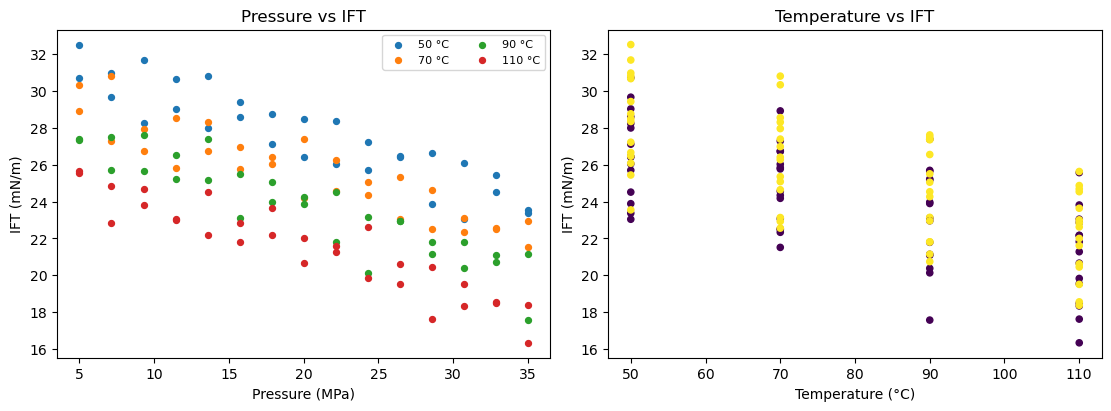

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for temperature, group in ift.groupby("temperature_c"):
    axes[0].scatter(group["pressure_mpa"], group["ift_mn_m"], label=f"{temperature:.0f} °C", s=18)
axes[0].set(xlabel="Pressure (MPa)", ylabel="IFT (mN/m)", title="Pressure vs IFT")
axes[0].legend(ncol=2, fontsize=8)
axes[1].scatter(ift["temperature_c"], ift["ift_mn_m"], c=ift["salinity_wt_pct"], cmap="viridis", s=20)
axes[1].set(xlabel="Temperature (°C)", ylabel="IFT (mN/m)", title="Temperature vs IFT")
plt.show()


## Challenge

        Fit and plot separate straight-line pressure trends for each temperature. Discuss why
        interpolation inside this synthetic table is different from physical extrapolation.